This script plots various aspects of the TrappedResonance objective function

In [1]:
import desc.io
from desc.objectives import (
    TrappedResonance
)
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [2]:
# User Inputs #
eq = desc.io.load("equil_Helios_E0092_DESC_fixed.h5")

rhos = (np.linspace(0.1,0.9,50))**(1/2) # rho = sqrt(s)
alphas = np.linspace(0,2*np.pi,3)
KE_frac = np.array([1]) #did 0.001 before
pitch_invs = jnp.array([6.55])
N=0 # QA

In [3]:
# Run objective function
obj = TrappedResonance(eq,rho=rhos,pitch_invs=pitch_invs,KE_frac=KE_frac,alpha=alphas,N=N)
obj.build()
out = obj.compute(eq.params_dict) # when not flattened, this shape is (rho,pitch,energy)

# Save objective function values to the firm3d directory for plotting with Poincare plots
# np.savetxt('/Users/paullab/codes/firm3d_fork_10132025/firm3d/examples/trapped_map/obj_DESC.txt',out['obj'][:,0,0]) # value at all surfaces and one pitch (and one energy)


Precomputing transforms


[-1.27535226 -1.23903983 -1.0836743  -0.950507   -0.82631933 -0.66148311
 -0.54392685 -0.44890641 -0.38967007 -0.3422607  -0.27409385 -0.21466478
 -0.18061613 -0.15881665 -0.13996304 -0.12033675 -0.10083375 -0.08387198
 -0.07030519 -0.0597242  -0.05130937 -0.04442572 -0.03858787 -0.03348823
 -0.02891847 -0.02473909 -0.02086852 -0.01726637 -0.01393381 -0.01090155
 -0.00822246 -0.00598505 -0.00431946 -0.00337204 -0.00330221 -0.00428423
 -0.00648995 -0.01010695 -0.01527748 -0.02205601 -0.03042371 -0.04013832
 -0.0505691  -0.06042897 -0.06749484 -0.06835672 -0.05923071 -0.03929709
 -0.01449906  0.00596293]
[0.00000000e+00 0.00000000e+00 0.00000000e+00 1.69921067e-80
 0.00000000e+00 1.51816299e+05 6.94545380e-01 0.00000000e+00
 0.00000000e+00 1.13153499e+04 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 3.99399056e-02 2.11041744e+03 7.94881318e+04
 5.42259003e+05 1.816708

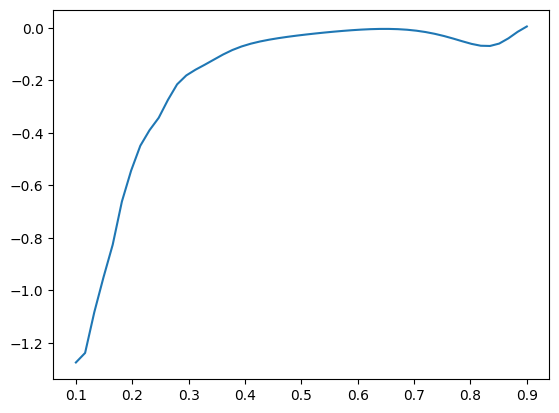

In [5]:
# testing
psi_da = out['psi_da']
obj_out = out['obj']
omega = out['omega']
# print(rhos**2) # index 12 is roughly s=0.6
# print(omega[:,0,0]) # rho,pitch,energy,res
plt.plot(rhos**2,omega[:,0,0,0])
# print(out['pitch_invs'])
print(omega[:,0,0,0])
print(out['obj'][:,0,0])

In [ ]:
# Plot s vs. obj_out for each pitch inverse
for i in range(0,obj_out.shape[1]): # loop through each pitch angle
    plt.figure(i+1)
    plt.plot(rhos**2,obj_out[:,i,0]) # assuming we are only doing 1 energy for now
    plt.xlabel(r'$s$')
    plt.ylabel('Objective Function Value')
    plt.title('TrappedResonance Objective Function Value for Pitch Inverse = '+str(pitch_invs[i]))
    # plt.ylabel(r'$\omega_{\zeta}$')
    # plt.title(r'$\omega_{\zeta}$ Value for Pitch Inverse = '+str(pitch_invs[i]))
    plt.xlim([0.0,1.0])

In [ ]:
# Plot the value of the TrappedResonance objective (summing over the rho axis) vs. pitch
obj_out = out['obj']
num_valid_pitch = jnp.sum(obj_out!=0,axis=0) # for each surface, how many pitches were valid

obj_out_rhosum = np.sum(obj_out,axis=0) / num_valid_pitch
np.savetxt('obj_pitch_plot.txt',obj_out_rhosum[:,0])
plt.figure()
plt.plot(pitch_invs,obj_out_rhosum[:,0]/np.nanmax(obj_out_rhosum[:,0]))
plt.title("TrappedResonance Objective Function Averaged Over All Surfaces")
plt.xlabel("Pitch Inverse [T]")
plt.ylabel("Objective Function Value")

In [51]:
np.savetxt('obj_s_out.txt',out['obj'][:,0,0]) # value at all surfaces

In [ ]:
obj_val = out['obj'][:,0,0]
Y = rhos**2
X = np.linspace(0,np.pi,5)
Z = np.transpose(np.tile(obj_val, (5, 1)))
plt.contourf(X,Y,Z)
plt.colorbar(label='Objective Function Value')